In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import re
import numpy as np

year= 2024
# Supongamos que tu dataset está en un DataFrame
df = pd.read_csv(f"final_data/season_players_dataset_with_context_{year}.csv")

# Separar variables independientes (X) y variable objetivo (y)
y = df['team_home_wins']
X = df.drop(['team_home_wins', 'game_id'], axis=1)

# Dividir en conjunto de entrenamiento y prueba
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.00001, random_state=42)

In [2]:
rf_model = RandomForestRegressor(n_estimators=1000, random_state=42)
rf_model.fit(X, y)

# Obtener importancias
rf_importances = rf_model.feature_importances_

# Mostrar resultados
importances_rf = pd.Series(rf_importances, index=X.columns).sort_values(ascending=False)


for i, col in enumerate(importances_rf.index):
    print(f"{i+1}. {col}: {importances_rf[col]:.8f}")

1. th_player1_PCA6_1: 0.33801454
2. ta_player1_PCA6_1: 0.12384257
3. th_player3_PCA6_1: 0.05292706
4. th_player2_PCA6_1: 0.03413319
5. ta_player1_PCA6_3: 0.03146885
6. ta_player2_PCA6_1: 0.02266371
7. ta_player2_PCA6_3: 0.02059817
8. th_player1_PCA6_3: 0.01488101
9. th_player2_PCA6_3: 0.01197848
10. th_player5_PCA6_3: 0.01180216
11. ta_player6_PCA6_3: 0.01102075
12. th_player6_PCA6_1: 0.01015372
13. th_player5_PCA6_1: 0.01009633
14. ta_player5_PCA6_1: 0.01005435
15. th_player4_PCA6_1: 0.00998676
16. th_player7_PCA6_1: 0.00927421
17. ta_player7_PCA6_1: 0.00896359
18. th_player4_PCA6_3: 0.00895190
19. ta_player6_PCA6_1: 0.00874597
20. ta_player3_PCA6_1: 0.00871038
21. th_player3_PCA6_3: 0.00769098
22. ta_player5_PCA6_3: 0.00720331
23. ta_player3_PCA6_3: 0.00714900
24. ta_player4_PCA6_1: 0.00510225
25. ta_player4_PCA6_3: 0.00383313
26. ta_player7_PCA6_3: 0.00377783
27. th_player6_PCA6_3: 0.00342047
28. th_player7_PCA6_3: 0.00191579
29. context4_ta_player3_PCA2_1: 0.00124039
30. context1_t

In [3]:
total = 0
for i, col in enumerate(importances_rf.index):
    total += importances_rf[col]

print(total)

1.0000000000000002


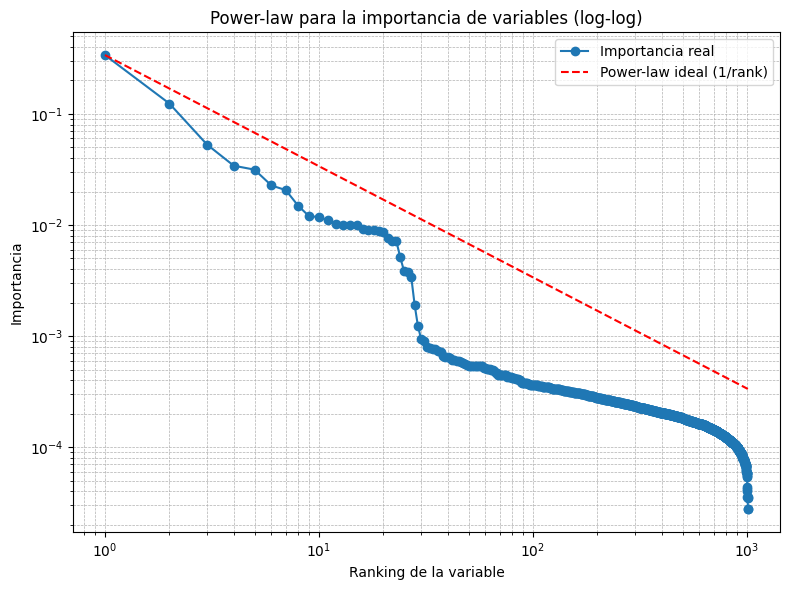

In [4]:
importances_sorted = importances_rf.sort_values(ascending=False)

# Asignar ranking (1 para la más importante, etc.)
ranking = np.arange(1, len(importances_sorted) + 1)

# Obtener valores de importancia
values = importances_sorted.values

s = 1  # Exponente de la ley de Zipf
zipf_ideal = values[0] / (ranking ** s)  # Normalizamos para que arranque en el mismo valor

# Gráfico
plt.figure(figsize=(8, 6))
plt.loglog(ranking, values, marker='o', linestyle='-', label='Importancia real')
plt.loglog(ranking, zipf_ideal, linestyle='--', color='red', label='Power-law ideal (1/rank)')

plt.title('Power-law para la importancia de variables (log-log)')
plt.xlabel('Ranking de la variable')
plt.ylabel('Importancia')
plt.legend()
plt.grid(True, which="both", linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

In [5]:
xgb_model = XGBRegressor(n_estimators=1000, random_state=42, objective="reg:squarederror")
xgb_model.fit(X, y)

# Obtener importancias
xgb_importances = xgb_model.feature_importances_

# Mostrar resultados
importances_xgb = pd.Series(xgb_importances, index=X.columns).sort_values(ascending=False)
for i, col in enumerate(importances_xgb.index):
    print(f"{i+1}. {col}: {importances_xgb[col]:.8f}")

1. th_player1_PCA6_1: 0.18227437
2. th_player3_PCA6_1: 0.05810643
3. ta_player3_historic_PCA2_1: 0.04342907
4. th_player7_historic_PCA3_1: 0.03265859
5. th_player2_PCA6_1: 0.03150954
6. th_player7_PCA6_1: 0.02793315
7. ta_player2_PCA6_3: 0.02385946
8. context4_ta_player2_PCA5_1: 0.01980712
9. context1_th_player7_PCA6_1: 0.01938771
10. ta_player1_PCA6_1: 0.01849063
11. th_player6_PCA6_1: 0.01833446
12. th_player4_PCA6_3: 0.01629851
13. context2_ta_player1_PCA2_2: 0.01465420
14. th_player5_PCA6_1: 0.01447231
15. context1_ta_player4_PCA1_1: 0.01366383
16. context4_ta_player1_PCA2_1: 0.01353746
17. th_player3_historic_PCA3_2: 0.01327657
18. context3_ta_player5_PCA4_2: 0.01327119
19. ta_player1_PCA6_3: 0.01270183
20. context4_ta_player1_PCA3_2: 0.01181595
21. ta_player2_PCA2_3: 0.01178732
22. context3_th_player1_PCA6_3: 0.01109157
23. th_player5_PCA6_3: 0.01067721
24. ta_player7_PCA6_1: 0.01061554
25. th_player4_PCA6_1: 0.01054365
26. ta_player3_PCA6_3: 0.01048582
27. context3_ta_player1_PC

In [6]:
total = 0
for i, col in enumerate(importances_xgb.index):
    total += importances_xgb[col]

print(total)

0.9999996


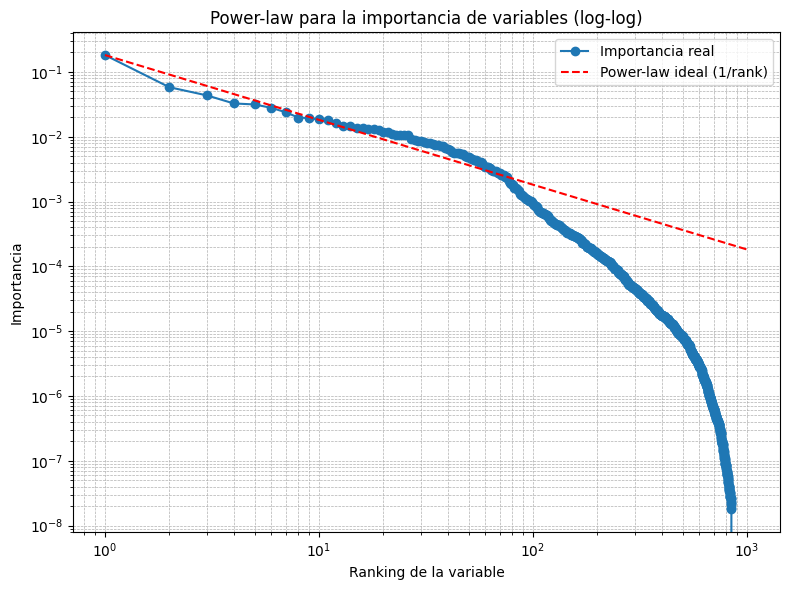

In [7]:
importances_sorted = importances_xgb.sort_values(ascending=False)

# Asignar ranking (1 para la más importante, etc.)
ranking = np.arange(1, len(importances_sorted) + 1)

# Obtener valores de importancia
values = importances_sorted.values

s = 1  # Exponente de la ley de Zipf
zipf_ideal = values[0] / (ranking ** s)  # Normalizamos para que arranque en el mismo valor

# Gráfico
plt.figure(figsize=(8, 6))
plt.loglog(ranking, values, marker='o', linestyle='-', label='Importancia real')
plt.loglog(ranking, zipf_ideal, linestyle='--', color='red', label='Power-law ideal (1/rank)')

plt.title('Power-law para la importancia de variables (log-log)')
plt.xlabel('Ranking de la variable')
plt.ylabel('Importancia')
plt.legend()
plt.grid(True, which="both", linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

In [8]:
filter_cols = [col for col in df.columns if not re.search(r'_(\d+)$', col) or int(re.search(r'_(\d+)$', col).group(1)) <= 3]
df_first_second_third_components = df[filter_cols]
y = df_first_second_third_components['team_home_wins']
X = df_first_second_third_components.drop(['team_home_wins', 'game_id'], axis=1)

In [9]:
rf_model = RandomForestRegressor(n_estimators=1000, random_state=42)
rf_model.fit(X, y)

# Obtener importancias
rf_importances = rf_model.feature_importances_

# Mostrar resultados
importances_rf = pd.Series(rf_importances, index=X.columns).sort_values(ascending=False)

total = 0
for i, col in enumerate(importances_rf.index):
    print(f"{i+1}. {col}: {importances_rf[col]:.8f}")
    total += importances_rf[col]

print(f"Total importance: {total}")

1. th_player1_PCA6_1: 0.33801454
2. ta_player1_PCA6_1: 0.12384257
3. th_player3_PCA6_1: 0.05292706
4. th_player2_PCA6_1: 0.03413319
5. ta_player1_PCA6_3: 0.03146885
6. ta_player2_PCA6_1: 0.02266371
7. ta_player2_PCA6_3: 0.02059817
8. th_player1_PCA6_3: 0.01488101
9. th_player2_PCA6_3: 0.01197848
10. th_player5_PCA6_3: 0.01180216
11. ta_player6_PCA6_3: 0.01102075
12. th_player6_PCA6_1: 0.01015372
13. th_player5_PCA6_1: 0.01009633
14. ta_player5_PCA6_1: 0.01005435
15. th_player4_PCA6_1: 0.00998676
16. th_player7_PCA6_1: 0.00927421
17. ta_player7_PCA6_1: 0.00896359
18. th_player4_PCA6_3: 0.00895190
19. ta_player6_PCA6_1: 0.00874597
20. ta_player3_PCA6_1: 0.00871038
21. th_player3_PCA6_3: 0.00769098
22. ta_player5_PCA6_3: 0.00720331
23. ta_player3_PCA6_3: 0.00714900
24. ta_player4_PCA6_1: 0.00510225
25. ta_player4_PCA6_3: 0.00383313
26. ta_player7_PCA6_3: 0.00377783
27. th_player6_PCA6_3: 0.00342047
28. th_player7_PCA6_3: 0.00191579
29. context4_ta_player3_PCA2_1: 0.00124039
30. context1_t

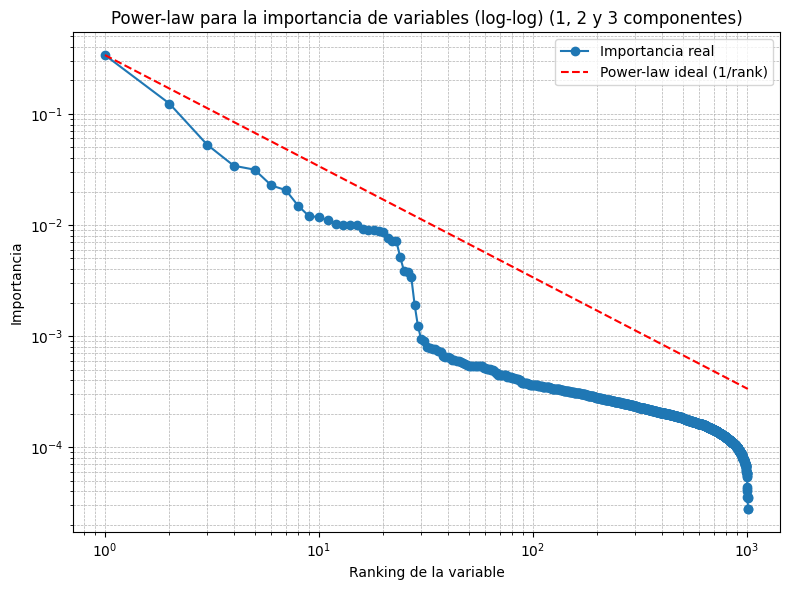

In [10]:
importances_sorted = importances_rf.sort_values(ascending=False)

# Asignar ranking (1 para la más importante, etc.)
ranking = np.arange(1, len(importances_sorted) + 1)

# Obtener valores de importancia
values = importances_sorted.values

s = 1  # Exponente de la ley de Zipf
zipf_ideal = values[0] / (ranking ** s)  # Normalizamos para que arranque en el mismo valor

# Gráfico
plt.figure(figsize=(8, 6))
plt.loglog(ranking, values, marker='o', linestyle='-', label='Importancia real')
plt.loglog(ranking, zipf_ideal, linestyle='--', color='red', label='Power-law ideal (1/rank)')

plt.title('Power-law para la importancia de variables (log-log) (1, 2 y 3 componentes)')
plt.xlabel('Ranking de la variable')
plt.ylabel('Importancia')
plt.legend()
plt.grid(True, which="both", linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

In [11]:
xgb_model = XGBRegressor(n_estimators=1000, random_state=42, objective="reg:squarederror")
xgb_model.fit(X, y)

# Obtener importancias
xgb_importances = xgb_model.feature_importances_

# Mostrar resultados
importances_xgb = pd.Series(xgb_importances, index=X.columns).sort_values(ascending=False)

total = 0
for i, col in enumerate(importances_xgb.index):
    print(f"{i+1}. {col}: {importances_xgb[col]:.8f}")
    total += importances_xgb[col]

print(f"Total importance: {total}")

1. th_player1_PCA6_1: 0.18227437
2. th_player3_PCA6_1: 0.05810643
3. ta_player3_historic_PCA2_1: 0.04342907
4. th_player7_historic_PCA3_1: 0.03265859
5. th_player2_PCA6_1: 0.03150954
6. th_player7_PCA6_1: 0.02793315
7. ta_player2_PCA6_3: 0.02385946
8. context4_ta_player2_PCA5_1: 0.01980712
9. context1_th_player7_PCA6_1: 0.01938771
10. ta_player1_PCA6_1: 0.01849063
11. th_player6_PCA6_1: 0.01833446
12. th_player4_PCA6_3: 0.01629851
13. context2_ta_player1_PCA2_2: 0.01465420
14. th_player5_PCA6_1: 0.01447231
15. context1_ta_player4_PCA1_1: 0.01366383
16. context4_ta_player1_PCA2_1: 0.01353746
17. th_player3_historic_PCA3_2: 0.01327657
18. context3_ta_player5_PCA4_2: 0.01327119
19. ta_player1_PCA6_3: 0.01270183
20. context4_ta_player1_PCA3_2: 0.01181595
21. ta_player2_PCA2_3: 0.01178732
22. context3_th_player1_PCA6_3: 0.01109157
23. th_player5_PCA6_3: 0.01067721
24. ta_player7_PCA6_1: 0.01061554
25. th_player4_PCA6_1: 0.01054365
26. ta_player3_PCA6_3: 0.01048582
27. context3_ta_player1_PC

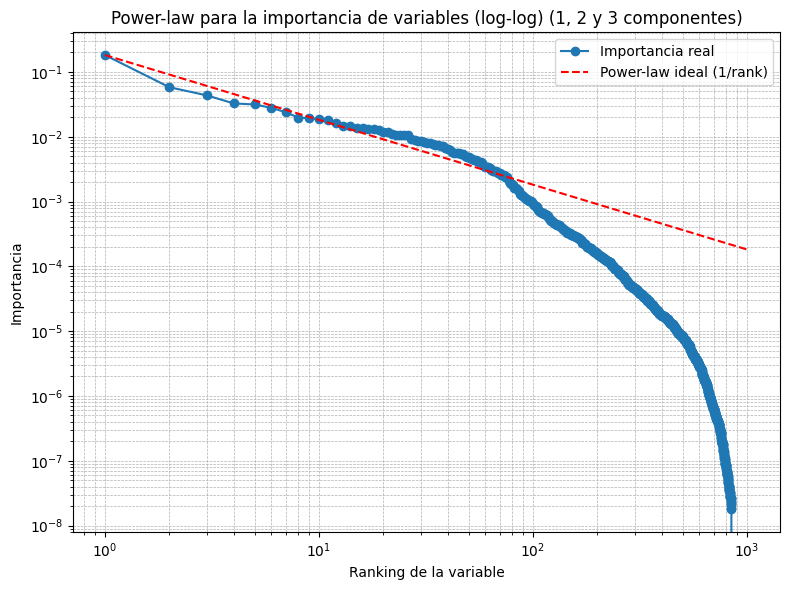

In [12]:
importances_sorted = importances_xgb.sort_values(ascending=False)

# Asignar ranking (1 para la más importante, etc.)
ranking = np.arange(1, len(importances_sorted) + 1)

# Obtener valores de importancia
values = importances_sorted.values

s = 1  # Exponente de la ley de Zipf
zipf_ideal = values[0] / (ranking ** s)  # Normalizamos para que arranque en el mismo valor

# Gráfico
plt.figure(figsize=(8, 6))
plt.loglog(ranking, values, marker='o', linestyle='-', label='Importancia real')
plt.loglog(ranking, zipf_ideal, linestyle='--', color='red', label='Power-law ideal (1/rank)')

plt.title('Power-law para la importancia de variables (log-log) (1, 2 y 3 componentes)')
plt.xlabel('Ranking de la variable')
plt.ylabel('Importancia')
plt.legend()
plt.grid(True, which="both", linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

In [13]:
filter_cols = [col for col in df.columns if not re.search(r'_(\d+)$', col) or int(re.search(r'_(\d+)$', col).group(1)) <= 2]
df_first_second_components = df[filter_cols]
y = df_first_second_components['team_home_wins']
X = df_first_second_components.drop(['team_home_wins', 'game_id'], axis=1)

In [14]:
rf_model = RandomForestRegressor(n_estimators=1000, random_state=42)
rf_model.fit(X, y)

# Obtener importancias
rf_importances = rf_model.feature_importances_

# Mostrar resultados
importances_rf = pd.Series(rf_importances, index=X.columns).sort_values(ascending=False)

total = 0
for i, col in enumerate(importances_rf.index):
    print(f"{i+1}. {col}: {importances_rf[col]:.8f}")
    total += importances_rf[col]

print(f"Total importance: {total}")

1. th_player1_PCA6_1: 0.35237911
2. ta_player1_PCA6_1: 0.13960760
3. th_player3_PCA6_1: 0.06280723
4. th_player2_PCA6_1: 0.04842604
5. ta_player2_PCA6_1: 0.03720216
6. th_player4_PCA6_1: 0.01853592
7. th_player5_PCA6_1: 0.01601331
8. th_player6_PCA6_1: 0.01566998
9. ta_player6_PCA6_1: 0.01440702
10. ta_player3_PCA6_1: 0.01431152
11. ta_player5_PCA6_1: 0.01369637
12. th_player7_PCA6_1: 0.01338469
13. ta_player7_PCA6_1: 0.01254769
14. ta_player4_PCA6_1: 0.00890816
15. context2_ta_player3_PCA6_2: 0.00134498
16. ta_player1_PCA5_1: 0.00124846
17. th_player1_PCA4_2: 0.00124753
18. ta_player4_PCA4_1: 0.00124682
19. th_player2_historic_PCA2_1: 0.00117240
20. th_player4_PCA4_1: 0.00114919
21. th_player7_historic_PCA5_1: 0.00113037
22. th_player2_historic_PCA3_2: 0.00112013
23. context4_ta_player3_PCA2_1: 0.00100323
24. context3_th_player2_PCA3_2: 0.00095069
25. ta_player4_PCA3_1: 0.00090129
26. context1_th_player5_PCA6_1: 0.00088769
27. context2_th_player3_PCA6_1: 0.00088578
28. context4_ta_pla

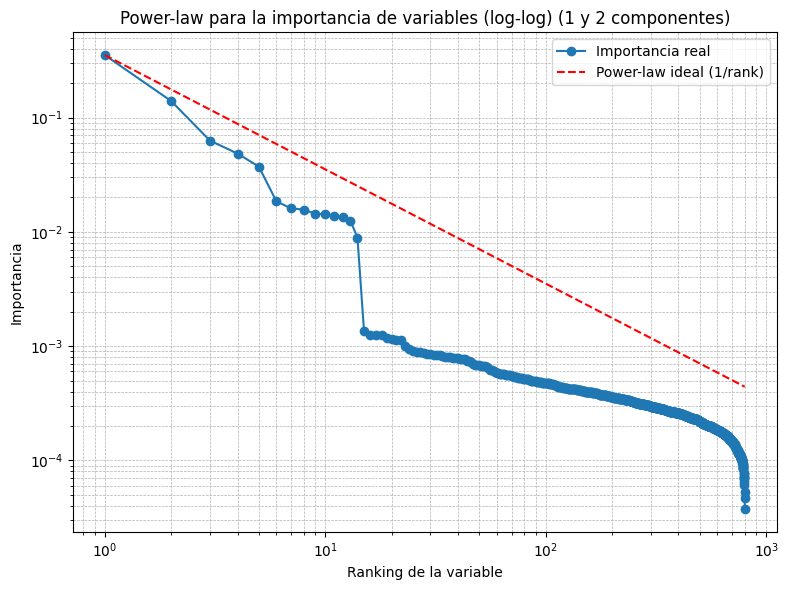

In [15]:
importances_sorted = importances_rf.sort_values(ascending=False)

# Asignar ranking (1 para la más importante, etc.)
ranking = np.arange(1, len(importances_sorted) + 1)

# Obtener valores de importancia
values = importances_sorted.values

s = 1  # Exponente de la ley de Zipf
zipf_ideal = values[0] / (ranking ** s)  # Normalizamos para que arranque en el mismo valor

# Gráfico
plt.figure(figsize=(8, 6))
plt.loglog(ranking, values, marker='o', linestyle='-', label='Importancia real')
plt.loglog(ranking, zipf_ideal, linestyle='--', color='red', label='Power-law ideal (1/rank)')

plt.title('Power-law para la importancia de variables (log-log) (1 y 2 componentes)')
plt.xlabel('Ranking de la variable')
plt.ylabel('Importancia')
plt.legend()
plt.grid(True, which="both", linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

In [16]:
xgb_model = XGBRegressor(n_estimators=1000, random_state=42, objective="reg:squarederror")
xgb_model.fit(X, y)

# Obtener importancias
xgb_importances = xgb_model.feature_importances_

# Mostrar resultados
importances_xgb = pd.Series(xgb_importances, index=X.columns).sort_values(ascending=False)

total = 0
for i, col in enumerate(importances_xgb.index):
    print(f"{i+1}. {col}: {importances_xgb[col]:.8f}")
    total += importances_xgb[col]

print(f"Total importance: {total}")

1. th_player1_PCA6_1: 0.17722020
2. th_player3_PCA6_1: 0.05430406
3. ta_player1_PCA6_1: 0.05365263
4. context2_th_player1_PCA3_2: 0.02262624
5. th_player2_PCA6_1: 0.02077562
6. context3_th_player5_PCA3_2: 0.01972101
7. ta_player5_PCA6_2: 0.01833933
8. th_player6_PCA6_1: 0.01822473
9. context4_ta_player5_PCA2_1: 0.01746220
10. th_player2_PCA2_1: 0.01727941
11. ta_player2_historic_PCA1_1: 0.01720935
12. context4_ta_player7_PCA3_2: 0.01710923
13. th_player7_PCA6_1: 0.01661045
14. th_player4_PCA6_1: 0.01567237
15. ta_player7_PCA6_1: 0.01563599
16. th_player5_PCA6_1: 0.01556945
17. context2_th_player5_PCA6_2: 0.01550553
18. ta_player5_PCA6_1: 0.01468578
19. th_player3_PCA4_1: 0.01442495
20. ta_player2_PCA6_1: 0.01418925
21. th_player5_PCA6_2: 0.01339615
22. th_player6_PCA2_1: 0.01242408
23. ta_player4_PCA6_1: 0.01231716
24. context4_th_player4_PCA5_1: 0.01128974
25. ta_player3_PCA6_1: 0.01091113
26. ta_player7_historic_PCA2_1: 0.01084044
27. context1_th_player2_PCA4_2: 0.01019176
28. contex

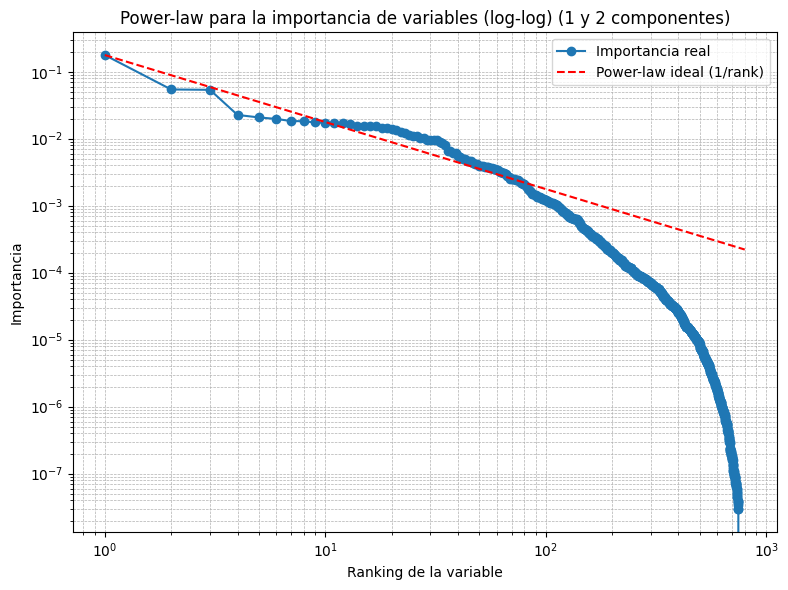

In [17]:
importances_sorted = importances_xgb.sort_values(ascending=False)

# Asignar ranking (1 para la más importante, etc.)
ranking = np.arange(1, len(importances_sorted) + 1)

# Obtener valores de importancia
values = importances_sorted.values

s = 1  # Exponente de la ley de Zipf
zipf_ideal = values[0] / (ranking ** s)  # Normalizamos para que arranque en el mismo valor

# Gráfico
plt.figure(figsize=(8, 6))
plt.loglog(ranking, values, marker='o', linestyle='-', label='Importancia real')
plt.loglog(ranking, zipf_ideal, linestyle='--', color='red', label='Power-law ideal (1/rank)')

plt.title('Power-law para la importancia de variables (log-log) (1 y 2 componentes)')
plt.xlabel('Ranking de la variable')
plt.ylabel('Importancia')
plt.legend()
plt.grid(True, which="both", linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

In [18]:
filter_cols = [col for col in df.columns if not re.search(r'_(\d+)$', col) or int(re.search(r'_(\d+)$', col).group(1)) <= 1]
df_first_components = df[filter_cols]
y = df_first_components['team_home_wins']
X = df_first_components.drop(['team_home_wins', 'game_id'], axis=1)

In [19]:
rf_model = RandomForestRegressor(n_estimators=1000, random_state=42)
rf_model.fit(X, y)

# Obtener importancias
rf_importances = rf_model.feature_importances_

# Mostrar resultados
importances_rf = pd.Series(rf_importances, index=X.columns).sort_values(ascending=False)

total = 0
for i, col in enumerate(importances_rf.index):
    print(f"{i+1}. {col}: {importances_rf[col]:.8f}")
    total += importances_rf[col]

print(f"Total importance: {total}")

1. th_player1_PCA6_1: 0.35384598
2. ta_player1_PCA6_1: 0.14041637
3. th_player3_PCA6_1: 0.06383896
4. th_player2_PCA6_1: 0.04972197
5. ta_player2_PCA6_1: 0.03837000
6. th_player4_PCA6_1: 0.01978160
7. th_player6_PCA6_1: 0.01749596
8. th_player5_PCA6_1: 0.01742786
9. ta_player6_PCA6_1: 0.01618396
10. ta_player5_PCA6_1: 0.01547230
11. ta_player3_PCA6_1: 0.01537809
12. ta_player7_PCA6_1: 0.01464475
13. th_player7_PCA6_1: 0.01462498
14. ta_player4_PCA6_1: 0.01001574
15. ta_player4_PCA4_1: 0.00189505
16. context4_ta_player3_PCA2_1: 0.00172261
17. ta_player1_PCA5_1: 0.00163636
18. th_player2_historic_PCA2_1: 0.00147796
19. th_player7_historic_PCA5_1: 0.00147360
20. th_player4_PCA4_1: 0.00134547
21. context2_th_player3_PCA6_1: 0.00130374
22. context1_th_player5_PCA6_1: 0.00129346
23. ta_player4_PCA3_1: 0.00126449
24. ta_player2_PCA5_1: 0.00124139
25. th_player2_PCA2_1: 0.00116894
26. context2_th_player3_PCA5_1: 0.00112646
27. context3_ta_player4_PCA1_1: 0.00111963
28. context4_ta_player3_PCA3

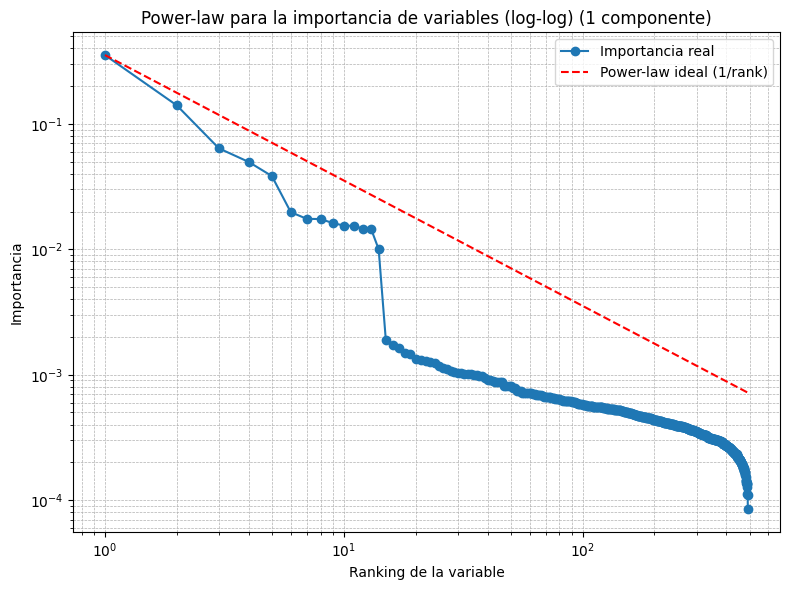

In [20]:
importances_sorted = importances_rf.sort_values(ascending=False)

# Asignar ranking (1 para la más importante, etc.)
ranking = np.arange(1, len(importances_sorted) + 1)

# Obtener valores de importancia
values = importances_sorted.values

s = 1  # Exponente de la ley de Zipf
zipf_ideal = values[0] / (ranking ** s)  # Normalizamos para que arranque en el mismo valor

# Gráfico
plt.figure(figsize=(8, 6))
plt.loglog(ranking, values, marker='o', linestyle='-', label='Importancia real')
plt.loglog(ranking, zipf_ideal, linestyle='--', color='red', label='Power-law ideal (1/rank)')

plt.title('Power-law para la importancia de variables (log-log) (1 componente)')
plt.xlabel('Ranking de la variable')
plt.ylabel('Importancia')
plt.legend()
plt.grid(True, which="both", linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

In [21]:
xgb_model = XGBRegressor(n_estimators=1000, random_state=42, objective="reg:squarederror")
xgb_model.fit(X, y)

# Obtener importancias
xgb_importances = xgb_model.feature_importances_

# Mostrar resultados
importances_xgb = pd.Series(xgb_importances, index=X.columns).sort_values(ascending=False)

total = 0
for i, col in enumerate(importances_xgb.index):
    print(f"{i+1}. {col}: {importances_xgb[col]:.8f}")
    total += importances_xgb[col]

print(f"Total importance: {total}")

1. th_player1_PCA6_1: 0.22302803
2. th_player3_PCA6_1: 0.08005910
3. context4_ta_player5_PCA2_1: 0.04790450
4. ta_player1_PCA6_1: 0.04104846
5. context3_th_player5_PCA6_1: 0.02768710
6. th_player6_PCA6_1: 0.02480558
7. th_player5_PCA6_1: 0.02222624
8. th_player3_historic_PCA3_1: 0.02177234
9. th_player7_PCA6_1: 0.02018853
10. th_player4_PCA6_1: 0.01864701
11. th_player2_PCA6_1: 0.01803121
12. ta_player6_PCA6_1: 0.01601609
13. context1_th_player5_PCA6_1: 0.01534991
14. ta_player2_PCA6_1: 0.01468766
15. context2_th_player3_PCA2_1: 0.01405821
16. ta_player7_PCA6_1: 0.01405432
17. ta_player4_PCA6_1: 0.01369392
18. context4_ta_player3_PCA5_1: 0.01307185
19. ta_player5_PCA6_1: 0.01264196
20. context1_ta_player7_PCA4_1: 0.01111668
21. context1_th_player5_PCA5_1: 0.01011691
22. context3_ta_player5_PCA5_1: 0.01005079
23. context1_ta_player5_PCA4_1: 0.01003114
24. context1_ta_player1_PCA1_1: 0.00981098
25. context3_ta_player7_PCA1_1: 0.00961512
26. ta_player6_historic_PCA2_1: 0.00892627
27. ta_p

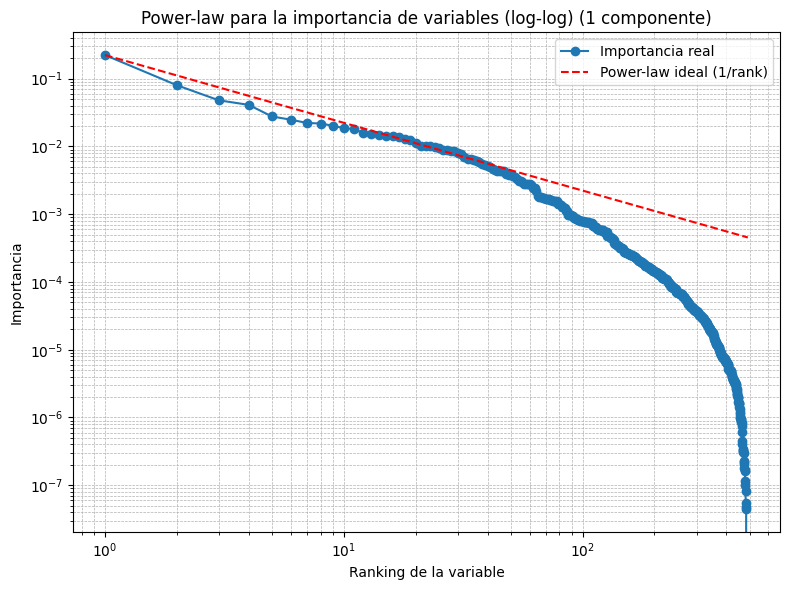

In [22]:
importances_sorted = importances_xgb.sort_values(ascending=False)

# Asignar ranking (1 para la más importante, etc.)
ranking = np.arange(1, len(importances_sorted) + 1)

# Obtener valores de importancia
values = importances_sorted.values

s = 1  # Exponente de la ley de Zipf
zipf_ideal = values[0] / (ranking ** s)  # Normalizamos para que arranque en el mismo valor

# Gráfico
plt.figure(figsize=(8, 6))
plt.loglog(ranking, values, marker='o', linestyle='-', label='Importancia real')
plt.loglog(ranking, zipf_ideal, linestyle='--', color='red', label='Power-law ideal (1/rank)')

plt.title('Power-law para la importancia de variables (log-log) (1 componente)')
plt.xlabel('Ranking de la variable')
plt.ylabel('Importancia')
plt.legend()
plt.grid(True, which="both", linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

In [23]:
year= 2024
# Supongamos que tu dataset está en un DataFrame
df = pd.read_csv(f"final_data/season_teams_dataset_with_context_{year}.csv")

# Separar variables independientes (X) y variable objetivo (y)
y = df['team_home_wins']
X = df.drop(['team_home_wins', 'game_id'], axis=1)
X = X.select_dtypes(exclude=['object', 'string'])

# Dividir en conjunto de entrenamiento y prueba
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.00001, random_state=42)

In [24]:
rf_model = RandomForestRegressor(n_estimators=1000, random_state=42)
rf_model.fit(X, y)

# Obtener importancias
rf_importances = rf_model.feature_importances_

# Mostrar resultados
importances_rf = pd.Series(rf_importances, index=X.columns).sort_values(ascending=False)


for i, col in enumerate(importances_rf.index):
    print(f"{i+1}. {col}: {importances_rf[col]:.8f}")

1. team_away_off_rtg: 0.19143449
2. team_home_def_rtg: 0.18703489
3. team_away_def_rtg: 0.17634030
4. team_home_off_rtg: 0.17423184
5. team_home_ts_pct: 0.05933686
6. team_home_pts: 0.03861125
7. team_away_ts_pct: 0.03316009
8. team_away_pts: 0.02023658
9. team_home_fg_pct: 0.00599249
10. team_away_pf: 0.00407819
11. team_home_efg_pct: 0.00382870
12. team_home_fta: 0.00299815
13. team_home_fg: 0.00270909
14. team_home_fta_per_fga_pct: 0.00260788
15. team_away_efg_pct: 0.00237398
16. team_away_fg_pct: 0.00228308
17. team_away_blk_pct: 0.00150673
18. context2_team_away_pf: 0.00117091
19. context4_team_home_orb: 0.00100269
20. context1_team_home_tov_pct: 0.00092894
21. context4_team_home_orb_pct: 0.00085296
22. context1_team_away_drb: 0.00076576
23. context4_team_away_drb_pct: 0.00075513
24. context4_team_away_stl_pct: 0.00073544
25. context1_team_away_ast_pct: 0.00070953
26. team_home_ft: 0.00070095
27. context1_team_away_trb_pct: 0.00069782
28. context2_team_away_fg3_pct: 0.00069551
29.

In [25]:
total = 0
for i, col in enumerate(importances_rf.index):
    total += importances_rf[col]

print(total)

0.9999999999999993


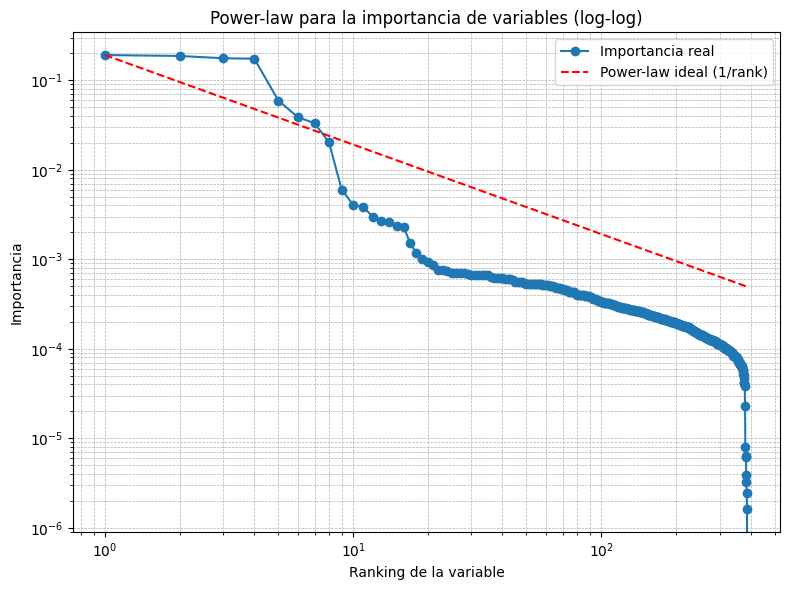

In [26]:
importances_sorted = importances_rf.sort_values(ascending=False)

# Asignar ranking (1 para la más importante, etc.)
ranking = np.arange(1, len(importances_sorted) + 1)

# Obtener valores de importancia
values = importances_sorted.values

s = 1  # Exponente de la ley de Zipf
zipf_ideal = values[0] / (ranking ** s)  # Normalizamos para que arranque en el mismo valor

# Gráfico
plt.figure(figsize=(8, 6))
plt.loglog(ranking, values, marker='o', linestyle='-', label='Importancia real')
plt.loglog(ranking, zipf_ideal, linestyle='--', color='red', label='Power-law ideal (1/rank)')

plt.title('Power-law para la importancia de variables (log-log)')
plt.xlabel('Ranking de la variable')
plt.ylabel('Importancia')
plt.legend()
plt.grid(True, which="both", linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

In [27]:
xgb_model = XGBRegressor(n_estimators=1000, random_state=42, objective="reg:squarederror")
xgb_model.fit(X, y)

# Obtener importancias
xgb_importances = xgb_model.feature_importances_

# Mostrar resultados
importances_xgb = pd.Series(xgb_importances, index=X.columns).sort_values(ascending=False)
for i, col in enumerate(importances_xgb.index):
    print(f"{i+1}. {col}: {importances_xgb[col]:.8f}")

1. team_away_off_rtg: 0.34400928
2. team_away_def_rtg: 0.29238105
3. team_home_pts: 0.12686010
4. context3_team_away_orb: 0.05992974
5. context4_team_home_orb: 0.03730930
6. context4_team_home_blk: 0.02938257
7. team_home_fg_pct: 0.02634887
8. team_away_fg3a: 0.01142272
9. team_away_fg_pct: 0.00968248
10. team_away_fg3_pct: 0.00933080
11. team_away_ast: 0.00787462
12. context3_team_home_fg_pct: 0.00744902
13. team_home_2020_historic_PCA3_1: 0.00611346
14. context2_team_home_drb_pct: 0.00337263
15. team_home_fta: 0.00272123
16. context3_team_away_fg3a: 0.00214962
17. context2_team_home_fg3: 0.00209789
18. context1_team_home_tov: 0.00192394
19. context1_team_away_drb: 0.00160750
20. context2_team_home_fg3_pct: 0.00160573
21. team_home_fg: 0.00126061
22. context3_team_away_fg3_pct: 0.00116022
23. team_away_fg: 0.00108655
24. team_home_ts_pct: 0.00099029
25. context4_team_away_ft_pct: 0.00079262
26. context2_team_home_pts: 0.00075689
27. team_away_ts_pct: 0.00070864
28. context1_team_away_

In [28]:
total = 0
for i, col in enumerate(importances_xgb.index):
    total += importances_xgb[col]

print(total)

1.0


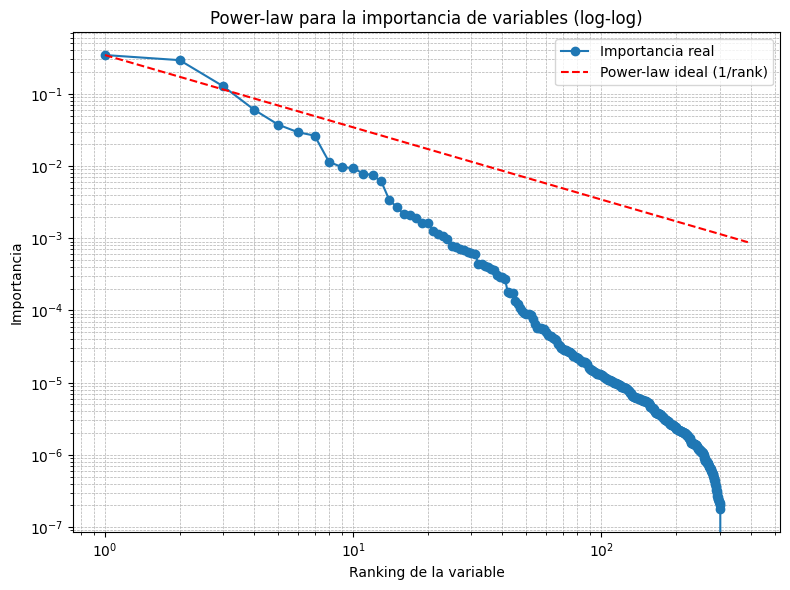

In [29]:
importances_sorted = importances_xgb.sort_values(ascending=False)

# Asignar ranking (1 para la más importante, etc.)
ranking = np.arange(1, len(importances_sorted) + 1)

# Obtener valores de importancia
values = importances_sorted.values

s = 1  # Exponente de la ley de Zipf
zipf_ideal = values[0] / (ranking ** s)  # Normalizamos para que arranque en el mismo valor

# Gráfico
plt.figure(figsize=(8, 6))
plt.loglog(ranking, values, marker='o', linestyle='-', label='Importancia real')
plt.loglog(ranking, zipf_ideal, linestyle='--', color='red', label='Power-law ideal (1/rank)')

plt.title('Power-law para la importancia de variables (log-log)')
plt.xlabel('Ranking de la variable')
plt.ylabel('Importancia')
plt.legend()
plt.grid(True, which="both", linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

In [30]:
filter_cols = [col for col in df.columns if not re.search(r'_(\d+)$', col) or int(re.search(r'_(\d+)$', col).group(1)) <= 3]
df_first_second_third_components = df[filter_cols]
y = df_first_second_third_components['team_home_wins']
X = df_first_second_third_components.drop(['team_home_wins', 'game_id'], axis=1)
X = df_first_second_third_components.select_dtypes(exclude=['object', 'string'])

In [31]:
rf_model = RandomForestRegressor(n_estimators=1000, random_state=42)
rf_model.fit(X, y)

# Obtener importancias
rf_importances = rf_model.feature_importances_

# Mostrar resultados
importances_rf = pd.Series(rf_importances, index=X.columns).sort_values(ascending=False)

total = 0
for i, col in enumerate(importances_rf.index):
    print(f"{i+1}. {col}: {importances_rf[col]:.8f}")
    total += importances_rf[col]

print(f"Total importance: {total}")

1. team_home_wins: 1.00000000
2. context4_team_away_blk: 0.00000000
3. team_away_fta: 0.00000000
4. context4_team_away_def_rtg: 0.00000000
5. team_away_fg: 0.00000000
6. team_away_fga: 0.00000000
7. team_away_fg_pct: 0.00000000
8. team_away_fg3: 0.00000000
9. team_away_orb_pct: 0.00000000
10. context4_team_away_fg: 0.00000000
11. context4_team_away_fga: 0.00000000
12. context4_team_away_fg_pct: 0.00000000
13. context4_team_away_fg3: 0.00000000
14. context4_team_away_fg3a: 0.00000000
15. context4_team_away_fg3_pct: 0.00000000
16. context4_team_away_ft: 0.00000000
17. context4_team_away_fta: 0.00000000
18. context4_team_away_ft_pct: 0.00000000
19. context4_team_away_orb: 0.00000000
20. context4_team_away_drb: 0.00000000
21. context4_team_away_trb: 0.00000000
22. context4_team_away_ast: 0.00000000
23. context4_team_away_stl: 0.00000000
24. team_away_fg3_pct: 0.00000000
25. team_away_drb_pct: 0.00000000
26. team_away_trb_pct: 0.00000000
27. team_away_ast_pct: 0.00000000
28. team_away_stl_p

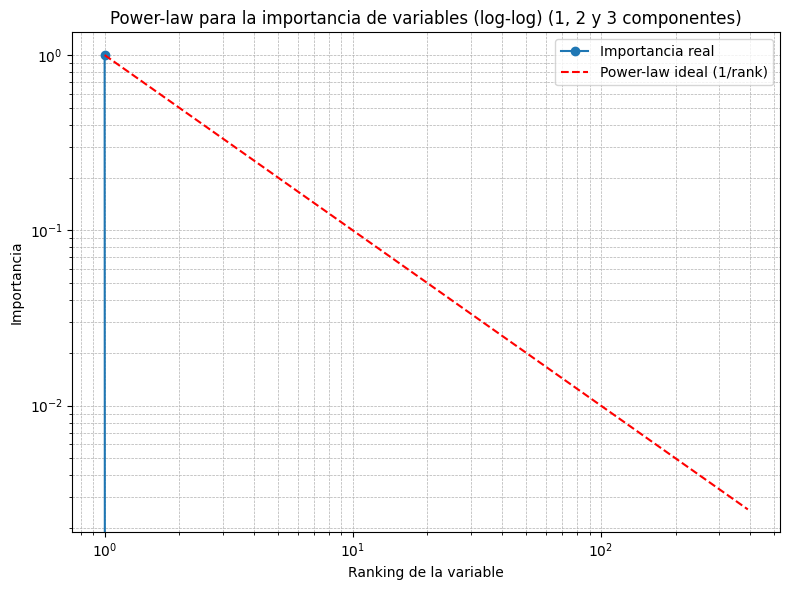

In [32]:
importances_sorted = importances_rf.sort_values(ascending=False)

# Asignar ranking (1 para la más importante, etc.)
ranking = np.arange(1, len(importances_sorted) + 1)

# Obtener valores de importancia
values = importances_sorted.values

s = 1  # Exponente de la ley de Zipf
zipf_ideal = values[0] / (ranking ** s)  # Normalizamos para que arranque en el mismo valor

# Gráfico
plt.figure(figsize=(8, 6))
plt.loglog(ranking, values, marker='o', linestyle='-', label='Importancia real')
plt.loglog(ranking, zipf_ideal, linestyle='--', color='red', label='Power-law ideal (1/rank)')

plt.title('Power-law para la importancia de variables (log-log) (1, 2 y 3 componentes)')
plt.xlabel('Ranking de la variable')
plt.ylabel('Importancia')
plt.legend()
plt.grid(True, which="both", linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

In [33]:
xgb_model = XGBRegressor(n_estimators=1000, random_state=42, objective="reg:squarederror")
xgb_model.fit(X, y)

# Obtener importancias
xgb_importances = xgb_model.feature_importances_

# Mostrar resultados
importances_xgb = pd.Series(xgb_importances, index=X.columns).sort_values(ascending=False)

total = 0
for i, col in enumerate(importances_xgb.index):
    print(f"{i+1}. {col}: {importances_xgb[col]:.8f}")
    total += importances_xgb[col]

print(f"Total importance: {total}")

1. team_home_wins: 1.00000000
2. context4_team_away_blk: 0.00000000
3. team_away_fta: 0.00000000
4. context4_team_away_def_rtg: 0.00000000
5. team_away_fg: 0.00000000
6. team_away_fga: 0.00000000
7. team_away_fg_pct: 0.00000000
8. team_away_fg3: 0.00000000
9. team_away_orb_pct: 0.00000000
10. context4_team_away_fg: 0.00000000
11. context4_team_away_fga: 0.00000000
12. context4_team_away_fg_pct: 0.00000000
13. context4_team_away_fg3: 0.00000000
14. context4_team_away_fg3a: 0.00000000
15. context4_team_away_fg3_pct: 0.00000000
16. context4_team_away_ft: 0.00000000
17. context4_team_away_fta: 0.00000000
18. context4_team_away_ft_pct: 0.00000000
19. context4_team_away_orb: 0.00000000
20. context4_team_away_drb: 0.00000000
21. context4_team_away_trb: 0.00000000
22. context4_team_away_ast: 0.00000000
23. context4_team_away_stl: 0.00000000
24. team_away_fg3_pct: 0.00000000
25. team_away_drb_pct: 0.00000000
26. team_away_trb_pct: 0.00000000
27. team_away_ast_pct: 0.00000000
28. team_away_stl_p

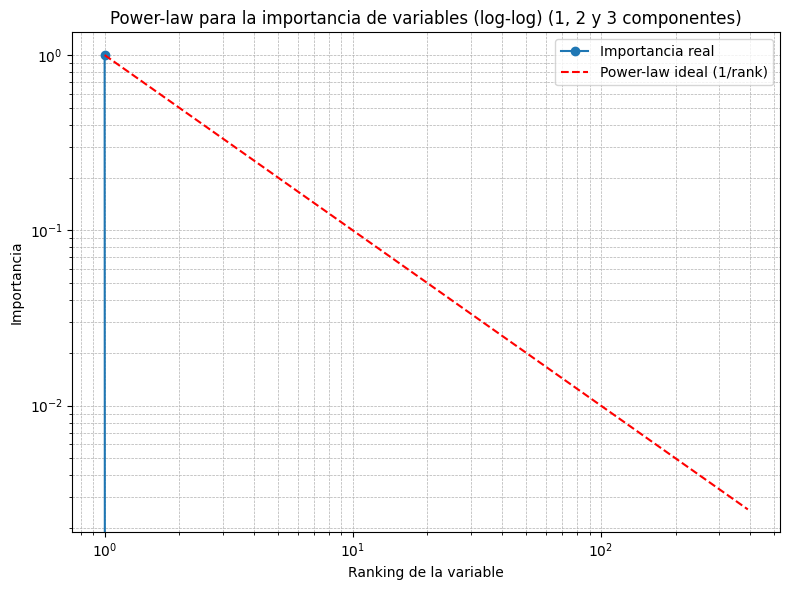

In [34]:
importances_sorted = importances_xgb.sort_values(ascending=False)

# Asignar ranking (1 para la más importante, etc.)
ranking = np.arange(1, len(importances_sorted) + 1)

# Obtener valores de importancia
values = importances_sorted.values

s = 1  # Exponente de la ley de Zipf
zipf_ideal = values[0] / (ranking ** s)  # Normalizamos para que arranque en el mismo valor

# Gráfico
plt.figure(figsize=(8, 6))
plt.loglog(ranking, values, marker='o', linestyle='-', label='Importancia real')
plt.loglog(ranking, zipf_ideal, linestyle='--', color='red', label='Power-law ideal (1/rank)')

plt.title('Power-law para la importancia de variables (log-log) (1, 2 y 3 componentes)')
plt.xlabel('Ranking de la variable')
plt.ylabel('Importancia')
plt.legend()
plt.grid(True, which="both", linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

In [35]:
filter_cols = [col for col in df.columns if not re.search(r'_(\d+)$', col) or int(re.search(r'_(\d+)$', col).group(1)) <= 2]
df_first_second_components = df[filter_cols]
y = df_first_second_components['team_home_wins']
X = df_first_second_components.drop(['team_home_wins', 'game_id'], axis=1)
X = df_first_second_components.select_dtypes(exclude=['object', 'string'])

In [36]:
rf_model = RandomForestRegressor(n_estimators=1000, random_state=42)
rf_model.fit(X, y)

# Obtener importancias
rf_importances = rf_model.feature_importances_

# Mostrar resultados
importances_rf = pd.Series(rf_importances, index=X.columns).sort_values(ascending=False)

total = 0
for i, col in enumerate(importances_rf.index):
    print(f"{i+1}. {col}: {importances_rf[col]:.8f}")
    total += importances_rf[col]

print(f"Total importance: {total}")

1. team_home_wins: 1.00000000
2. context4_team_away_blk: 0.00000000
3. team_away_fta: 0.00000000
4. context4_team_away_def_rtg: 0.00000000
5. team_away_fg: 0.00000000
6. team_away_fga: 0.00000000
7. team_away_fg_pct: 0.00000000
8. team_away_fg3: 0.00000000
9. team_away_orb_pct: 0.00000000
10. context4_team_away_fg: 0.00000000
11. context4_team_away_fga: 0.00000000
12. context4_team_away_fg_pct: 0.00000000
13. context4_team_away_fg3: 0.00000000
14. context4_team_away_fg3a: 0.00000000
15. context4_team_away_fg3_pct: 0.00000000
16. context4_team_away_ft: 0.00000000
17. context4_team_away_fta: 0.00000000
18. context4_team_away_ft_pct: 0.00000000
19. context4_team_away_orb: 0.00000000
20. context4_team_away_drb: 0.00000000
21. context4_team_away_trb: 0.00000000
22. context4_team_away_ast: 0.00000000
23. context4_team_away_stl: 0.00000000
24. team_away_fg3_pct: 0.00000000
25. team_away_drb_pct: 0.00000000
26. team_away_trb_pct: 0.00000000
27. team_away_ast_pct: 0.00000000
28. team_away_stl_p

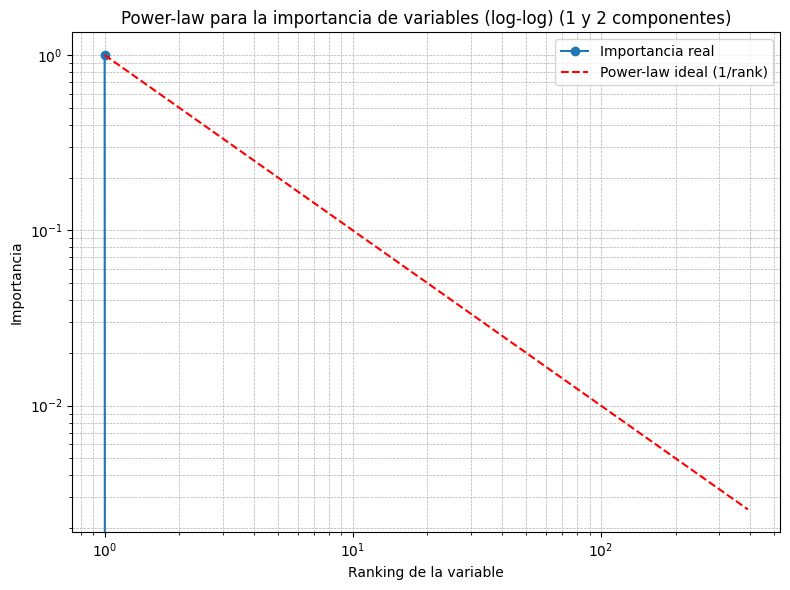

In [37]:
importances_sorted = importances_rf.sort_values(ascending=False)

# Asignar ranking (1 para la más importante, etc.)
ranking = np.arange(1, len(importances_sorted) + 1)

# Obtener valores de importancia
values = importances_sorted.values

s = 1  # Exponente de la ley de Zipf
zipf_ideal = values[0] / (ranking ** s)  # Normalizamos para que arranque en el mismo valor

# Gráfico
plt.figure(figsize=(8, 6))
plt.loglog(ranking, values, marker='o', linestyle='-', label='Importancia real')
plt.loglog(ranking, zipf_ideal, linestyle='--', color='red', label='Power-law ideal (1/rank)')

plt.title('Power-law para la importancia de variables (log-log) (1 y 2 componentes)')
plt.xlabel('Ranking de la variable')
plt.ylabel('Importancia')
plt.legend()
plt.grid(True, which="both", linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

In [38]:
xgb_model = XGBRegressor(n_estimators=1000, random_state=42, objective="reg:squarederror")
xgb_model.fit(X, y)

# Obtener importancias
xgb_importances = xgb_model.feature_importances_

# Mostrar resultados
importances_xgb = pd.Series(xgb_importances, index=X.columns).sort_values(ascending=False)

total = 0
for i, col in enumerate(importances_xgb.index):
    print(f"{i+1}. {col}: {importances_xgb[col]:.8f}")
    total += importances_xgb[col]

print(f"Total importance: {total}")

1. team_home_wins: 1.00000000
2. context4_team_away_blk: 0.00000000
3. team_away_fta: 0.00000000
4. context4_team_away_def_rtg: 0.00000000
5. team_away_fg: 0.00000000
6. team_away_fga: 0.00000000
7. team_away_fg_pct: 0.00000000
8. team_away_fg3: 0.00000000
9. team_away_orb_pct: 0.00000000
10. context4_team_away_fg: 0.00000000
11. context4_team_away_fga: 0.00000000
12. context4_team_away_fg_pct: 0.00000000
13. context4_team_away_fg3: 0.00000000
14. context4_team_away_fg3a: 0.00000000
15. context4_team_away_fg3_pct: 0.00000000
16. context4_team_away_ft: 0.00000000
17. context4_team_away_fta: 0.00000000
18. context4_team_away_ft_pct: 0.00000000
19. context4_team_away_orb: 0.00000000
20. context4_team_away_drb: 0.00000000
21. context4_team_away_trb: 0.00000000
22. context4_team_away_ast: 0.00000000
23. context4_team_away_stl: 0.00000000
24. team_away_fg3_pct: 0.00000000
25. team_away_drb_pct: 0.00000000
26. team_away_trb_pct: 0.00000000
27. team_away_ast_pct: 0.00000000
28. team_away_stl_p

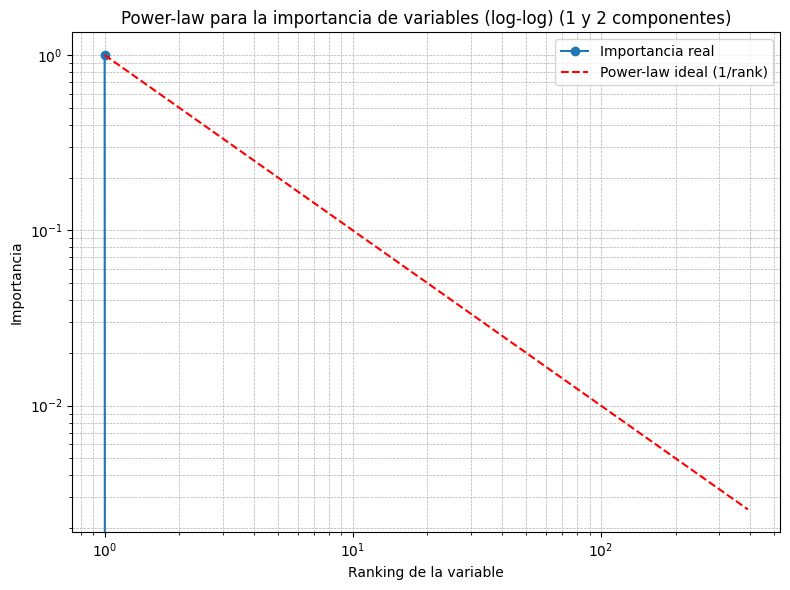

In [39]:
importances_sorted = importances_xgb.sort_values(ascending=False)

# Asignar ranking (1 para la más importante, etc.)
ranking = np.arange(1, len(importances_sorted) + 1)

# Obtener valores de importancia
values = importances_sorted.values

s = 1  # Exponente de la ley de Zipf
zipf_ideal = values[0] / (ranking ** s)  # Normalizamos para que arranque en el mismo valor

# Gráfico
plt.figure(figsize=(8, 6))
plt.loglog(ranking, values, marker='o', linestyle='-', label='Importancia real')
plt.loglog(ranking, zipf_ideal, linestyle='--', color='red', label='Power-law ideal (1/rank)')

plt.title('Power-law para la importancia de variables (log-log) (1 y 2 componentes)')
plt.xlabel('Ranking de la variable')
plt.ylabel('Importancia')
plt.legend()
plt.grid(True, which="both", linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

In [40]:
filter_cols = [col for col in df.columns if not re.search(r'_(\d+)$', col) or int(re.search(r'_(\d+)$', col).group(1)) <= 1]
df_first_components = df[filter_cols]
y = df_first_components['team_home_wins']
X = df_first_components.drop(['team_home_wins', 'game_id'], axis=1)
X = df_first_components.select_dtypes(exclude=['object', 'string'])

In [41]:
rf_model = RandomForestRegressor(n_estimators=1000, random_state=42)
rf_model.fit(X, y)

# Obtener importancias
rf_importances = rf_model.feature_importances_

# Mostrar resultados
importances_rf = pd.Series(rf_importances, index=X.columns).sort_values(ascending=False)

total = 0
for i, col in enumerate(importances_rf.index):
    print(f"{i+1}. {col}: {importances_rf[col]:.8f}")
    total += importances_rf[col]

print(f"Total importance: {total}")

1. team_home_wins: 1.00000000
2. team_away_fg_pct: 0.00000000
3. context3_team_away_def_rtg: 0.00000000
4. team_away_ts_pct: 0.00000000
5. team_away_fg: 0.00000000
6. context4_team_away_fg: 0.00000000
7. context4_team_away_fga: 0.00000000
8. context4_team_away_fg_pct: 0.00000000
9. context4_team_away_fg3: 0.00000000
10. context4_team_away_fg3a: 0.00000000
11. context4_team_away_fg3_pct: 0.00000000
12. context4_team_away_ft: 0.00000000
13. context4_team_away_fta: 0.00000000
14. context4_team_away_ft_pct: 0.00000000
15. context4_team_away_orb: 0.00000000
16. context4_team_away_drb: 0.00000000
17. context4_team_away_trb: 0.00000000
18. context4_team_away_ast: 0.00000000
19. context4_team_away_stl: 0.00000000
20. context4_team_away_blk: 0.00000000
21. team_away_efg_pct: 0.00000000
22. team_away_fg3a_per_fga_pct: 0.00000000
23. team_away_fta_per_fga_pct: 0.00000000
24. team_away_orb_pct: 0.00000000
25. team_away_drb_pct: 0.00000000
26. team_away_trb_pct: 0.00000000
27. team_away_ast_pct: 0.

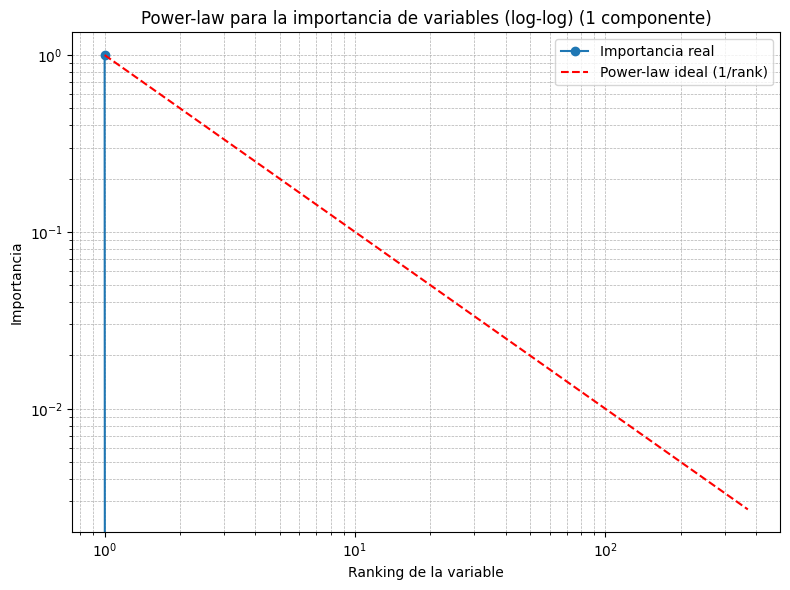

In [42]:
importances_sorted = importances_rf.sort_values(ascending=False)

# Asignar ranking (1 para la más importante, etc.)
ranking = np.arange(1, len(importances_sorted) + 1)

# Obtener valores de importancia
values = importances_sorted.values

s = 1  # Exponente de la ley de Zipf
zipf_ideal = values[0] / (ranking ** s)  # Normalizamos para que arranque en el mismo valor

# Gráfico
plt.figure(figsize=(8, 6))
plt.loglog(ranking, values, marker='o', linestyle='-', label='Importancia real')
plt.loglog(ranking, zipf_ideal, linestyle='--', color='red', label='Power-law ideal (1/rank)')

plt.title('Power-law para la importancia de variables (log-log) (1 componente)')
plt.xlabel('Ranking de la variable')
plt.ylabel('Importancia')
plt.legend()
plt.grid(True, which="both", linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

In [43]:
xgb_model = XGBRegressor(n_estimators=1000, random_state=42, objective="reg:squarederror")
xgb_model.fit(X, y)

# Obtener importancias
xgb_importances = xgb_model.feature_importances_

# Mostrar resultados
importances_xgb = pd.Series(xgb_importances, index=X.columns).sort_values(ascending=False)

total = 0
for i, col in enumerate(importances_xgb.index):
    print(f"{i+1}. {col}: {importances_xgb[col]:.8f}")
    total += importances_xgb[col]

print(f"Total importance: {total}")

1. team_home_wins: 1.00000000
2. team_away_fg_pct: 0.00000000
3. context3_team_away_def_rtg: 0.00000000
4. team_away_ts_pct: 0.00000000
5. team_away_fg: 0.00000000
6. context4_team_away_fg: 0.00000000
7. context4_team_away_fga: 0.00000000
8. context4_team_away_fg_pct: 0.00000000
9. context4_team_away_fg3: 0.00000000
10. context4_team_away_fg3a: 0.00000000
11. context4_team_away_fg3_pct: 0.00000000
12. context4_team_away_ft: 0.00000000
13. context4_team_away_fta: 0.00000000
14. context4_team_away_ft_pct: 0.00000000
15. context4_team_away_orb: 0.00000000
16. context4_team_away_drb: 0.00000000
17. context4_team_away_trb: 0.00000000
18. context4_team_away_ast: 0.00000000
19. context4_team_away_stl: 0.00000000
20. context4_team_away_blk: 0.00000000
21. team_away_efg_pct: 0.00000000
22. team_away_fg3a_per_fga_pct: 0.00000000
23. team_away_fta_per_fga_pct: 0.00000000
24. team_away_orb_pct: 0.00000000
25. team_away_drb_pct: 0.00000000
26. team_away_trb_pct: 0.00000000
27. team_away_ast_pct: 0.

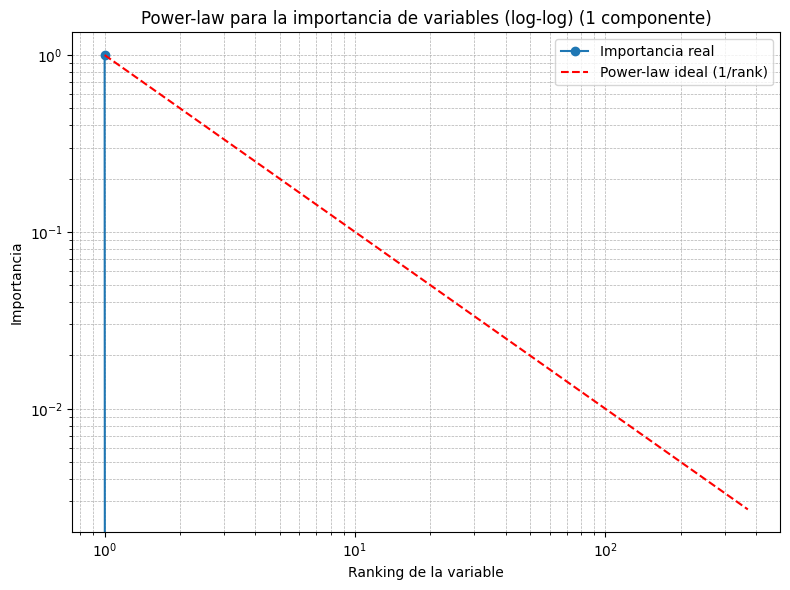

In [44]:
importances_sorted = importances_xgb.sort_values(ascending=False)

# Asignar ranking (1 para la más importante, etc.)
ranking = np.arange(1, len(importances_sorted) + 1)

# Obtener valores de importancia
values = importances_sorted.values

s = 1  # Exponente de la ley de Zipf
zipf_ideal = values[0] / (ranking ** s)  # Normalizamos para que arranque en el mismo valor

# Gráfico
plt.figure(figsize=(8, 6))
plt.loglog(ranking, values, marker='o', linestyle='-', label='Importancia real')
plt.loglog(ranking, zipf_ideal, linestyle='--', color='red', label='Power-law ideal (1/rank)')

plt.title('Power-law para la importancia de variables (log-log) (1 componente)')
plt.xlabel('Ranking de la variable')
plt.ylabel('Importancia')
plt.legend()
plt.grid(True, which="both", linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()